## 概述
探索自然语言文本中词元的统计分布和多种分词方法
字符集分词和词级分词

## 目标
* 对数据集进行预处理和计数统计
* 将词频分布与奇普夫定律联系起来
* 观察字符级分词与词级分词对序列长度与词汇量的影响

### 导入依赖和数据

In [3]:
%%capture
# Install the custom package for this course.
!pip install "git+https://github.com/google-deepmind/ai-foundations.git@main"
import re
import pandas as pd
import textwrap
from collections import Counter
from ai_foundations import visualizations  # For visualizations.
from ai_foundations.feedback.course_2 import tokenize  # For providing feedback.
import jieba

In [11]:
africa_galore = pd.read_json("测试.json")
dataset = africa_galore["content"].values
print("Loaded dataset with", dataset.shape[0], "paragraphs.\n")
print(f"The first paragraph is:\n{textwrap.fill(dataset[0])}")

Loaded dataset with 15 paragraphs.

The first paragraph is:
后端架构组已完成对 Spring Cloud 微服务的整合，引入了 Seata 处理分布式事务。本次重构提升了 20% 的系统响应速度。


### 分词

In [16]:
def preprocess_text(paragraphs: list[str]) -> list[str]:
    token_list = []
    for paragraph in paragraphs:
        # r'\b\w+\b' 匹配一个完整的单词
        #for token in re.findall(r'\b\w+\b', text):
        words = jieba.cut(paragraph.lower())
        for word in words:
            word = word.strip()
            # 这里的正则确保我们只收集有意义的内容，跳过类似 "，" 或 "。" 的符号
            if word and re.search(r'[\w\u4e00-\u9fa5]', word):
                token_list.append(word)
    return token_list


tokens_list = preprocess_text(dataset)
print(tokens_list[:10])

['后', '端', '架构', '组已', '完成', '对', 'spring', 'cloud', '微', '服务']


In [19]:
# 计算单词出现的频率
def get_token_counts(tokens: list[str]) -> Counter[str]:
    token_counts = Counter(tokens)
    return token_counts
token_counts = get_token_counts(tokens_list)
list(token_counts.most_common(10))

[('的', 23),
 ('了', 8),
 ('服务', 4),
 ('在', 4),
 ('已', 4),
 ('端', 3),
 ('完成', 3),
 ('系统', 3),
 ('中', 3),
 ('至', 3)]

### 奇普夫定律
* 对词元出现频率排序
* 少数词频率高，大多数词频率低，长尾分布
* 标准比例尺绘制关系图会难以辨认
* 使用双对数图（排名的对数和频率的对数）

C:\guangtao\fileRepository\ai-foundation\course2\.venv\Lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\guangtao\fileRepository\ai-foundation\course2\.venv\Lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 20102 (\N{CJK UNIFIED IDEOGRAPH-4E86}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\guangtao\fileRepository\ai-foundation\course2\.venv\Lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 26381 (\N{CJK UNIFIED IDEOGRAPH-670D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\guangtao\fileRepository\ai-foundation\course2\.venv\Lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 21153 (\N{CJK UNIFIED IDEOGRAPH-52A1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\guangtao\fileRepository\ai-foundation\cou

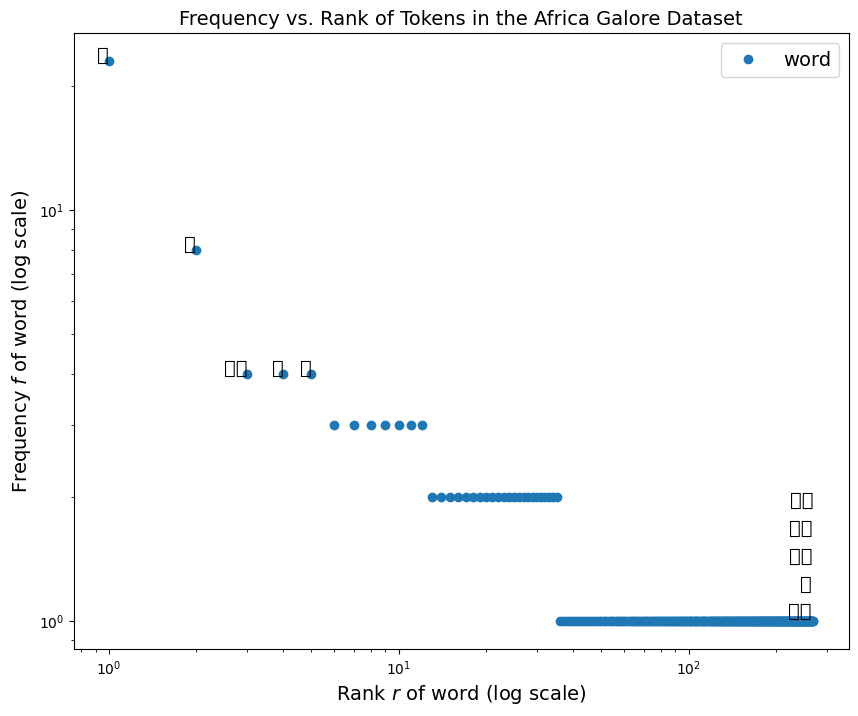

In [20]:
visualizations.plot_word_frequencies(token_counts)

### 分词


In [21]:
sample_text = dataset[0]
print(textwrap.fill(sample_text))

后端架构组已完成对 Spring Cloud 微服务的整合，引入了 Seata 处理分布式事务。本次重构提升了 20% 的系统响应速度。


## 概况
* 分词单元的选择会影响文本翻译成的序列长度以及分词器的词汇量
* 对分词的深入理解对于构建和部署有效的自然语言处理模型至关重要。周密的分词策略可以显著提升模型性能，并确保模型在处理各种语言输入时都具有鲁棒性